In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.stats import kruskal
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "행정동_분기_마스터(최종).csv", encoding="utf-8-sig")

### 개업율 & 프랜차이즈 침투율

In [3]:
df2 = df.copy()

In [4]:
df2.columns

Index(['base_quarter', 'year', 'quarter', 'adm_dong_cd', 'adm_dong_nm', 'gu', 'floating_pop', 'purpose_0_ratio', 'purpose_1_ratio', 'purpose_2_ratio', 'purpose_3_ratio', 'purpose_4_ratio',
       'purpose_5_ratio', 'purpose_6_ratio', 'external_inflow', 'stay_time_weighted', 'stay_time_cnt', 'transport_total_cnt', 'transport_0_ratio', 'transport_1_ratio', 'transport_2_ratio',
       'transport_3_ratio', 'transport_4_ratio', 'transport_5_ratio', 'transport_6_ratio', 'transport_7_ratio', 'sales_amt', 'sales_cnt', 'avg_ticket', 'new_corp_cnt', 'store_mer_cnt',
       'franchise_cnt', 'open_cnt', 'close_cnt', 'open_rate', 'close_rate', 'franchise_ratio', 'industry_diversity_H', 'survival_rate_1y', 'bus_board_cnt', 'bus_alight_cnt', '전입_소득수준_가중평균',
       '전출_소득수준_가중평균', '전입_총인원', '전입_고소득층_인원', '전입_고소득층_비율', '전입_소득수준_가중평균_분기'],
      dtype='str')

In [5]:
data = df2.groupby(["base_quarter", "adm_dong_nm"]).agg({"franchise_cnt": "mean", "open_cnt": "mean"})

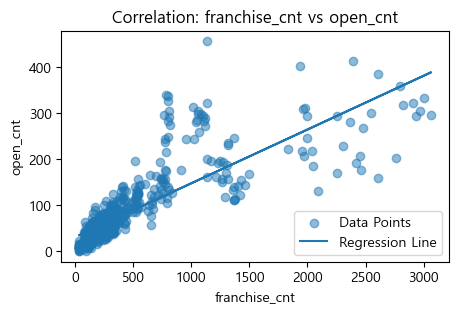

Pearson  | 계수: 0.8223, p-value: 0.0000
Spearman | 계수: 0.8987, p-value: 0.0000




In [6]:
x = data['franchise_cnt']
y = data['open_cnt']

# 1. 시각화
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.5, label='Data Points')

# 회귀선 계산 및 그리기
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, label=f'Regression Line')

plt.xlabel("franchise_cnt")
plt.ylabel("open_cnt")
plt.title("Correlation: franchise_cnt vs open_cnt")
plt.legend()
plt.show()

# 2. 통계 검정 (Pearson & Spearman)
pearson_r, p_p = stats.pearsonr(x, y)
spearman_r, p_s = stats.spearmanr(x, y)

print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
print("\n")

### 객단가 & 신규점포 잔존율
- 객단가: 고객 1인당 평균 (카드)소비금액

In [7]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]

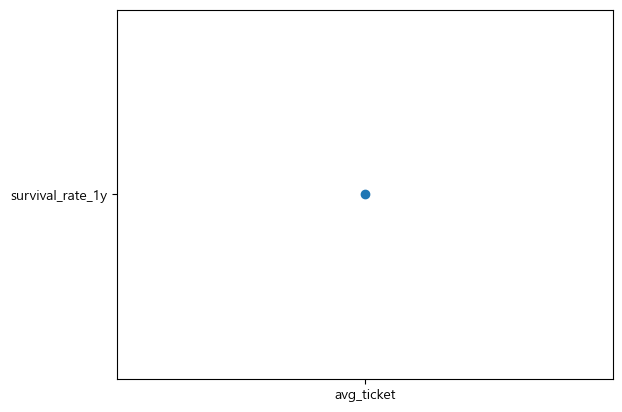

In [8]:
plt.scatter(data = data, x="avg_ticket", y="survival_rate_1y")

In [9]:
data.corr(method="pearson") # 거의 상관 없음

,franchise_cnt,open_cnt
franchise_cnt,1.000000,0.822295
open_cnt,0.822295,1.000000


In [10]:
data.corr(method="spearman")

,franchise_cnt,open_cnt
franchise_cnt,1.000000,0.898673
open_cnt,0.898673,1.000000


In [11]:
data.corr(method="kendall")

,franchise_cnt,open_cnt
franchise_cnt,1.000000,0.729653
open_cnt,0.729653,1.000000


객단가와 신규점포 잔존율은 '거의 상관 없음'

- 귀무가설: 객단가와 신규점포 잔존율은 상관이 없다
- 대립가설: 객단가와 신규점포 잔존율는 양의 상관이 있다.

In [12]:
# r, p_value = stats.pearsonr(data['avg_ticket'], data['survival_rate_1y'])
# print(f'상관계수: {r:.4f}')
# print(f'p-value: {p_value:.4f}')

In [13]:
# r, p_value = stats.spearmanr(data['avg_ticket'], data['survival_rate_1y'])
# print(f'상관계수: {r:.4f}')
# print(f'p-value: {p_value:.4f}')

p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 객단가와 신규점포 잔존율 간에 통계적으로 유의한 양의 상관이 확인됐으나 상관의 크기가 매우 작아 객단가만으로 잔존율을 예측하기는 어렵다.

### 신규기업 수 & 폐업한 점포 수

In [14]:
data_corp = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "close_cnt": "sum"})

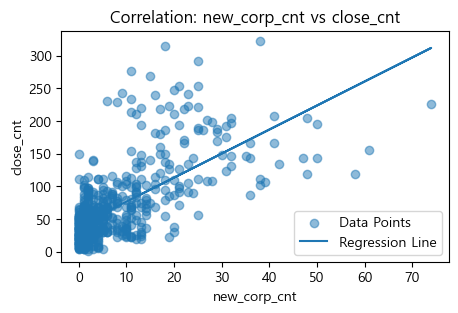

Pearson  | 계수: 0.6675, p-value: 0.0000
Spearman | 계수: 0.6139, p-value: 0.0000




NameError: name 'data_fran' is not defined

In [15]:
x = data_corp['new_corp_cnt']
y = data_corp['close_cnt']

# 1. 시각화
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.5, label='Data Points')

# 회귀선 계산 및 그리기
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, label=f'Regression Line')

plt.xlabel('new_corp_cnt')
plt.ylabel("close_cnt")
plt.title("Correlation: new_corp_cnt vs close_cnt")
plt.legend()
plt.show()

# 2. 통계 검정 (Pearson & Spearman)
pearson_r, p_p = stats.pearsonr(x, y)
spearman_r, p_s = stats.spearmanr(x, y)

print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
print("\n")

plt.scatter(data = data_fran, x="new_corp_cnt", y="franchise_cnt")

In [ ]:
data_corp.corr(method="pearson")

In [ ]:
data_corp.corr(method="spearman")

In [ ]:
data_corp.corr(method="kendall")

신규기업 수와 폐업한 점포 수는 '중간 정도 상관'

- 귀무가설: 신규 기업 수와 폐업 점포 수는 상관이 없다
- 대립가설: 신규 기업 수와 폐업 점포 수는 양의 상관이 있다.

In [ ]:
r, p_value = stats.pearsonr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

In [ ]:
r, p_value = stats.spearmanr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 신규 기업 수가 늘어날 때 폐업 점포 수도 늘어난다.

### 신규기업 수 & 프랜차이즈 수

In [ ]:
data_fran = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "franchise_cnt": "sum"})

In [ ]:
x = data_fran['new_corp_cnt']
y = data_fran['franchise_cnt']

# 1. 시각화
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.5, label='Data Points')

# 회귀선 계산 및 그리기
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, label=f'Regression Line')

plt.xlabel('new_corp_cnt')
plt.ylabel("franchise_cnt")
plt.title("Correlation: new_corp_cnt vs franchise_cnt")
plt.legend()
plt.show()

# 2. 통계 검정 (Pearson & Spearman)
pearson_r, p_p = stats.pearsonr(x, y)
spearman_r, p_s = stats.spearmanr(x, y)

print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
print("\n")

plt.scatter(data = data_fran, x="new_corp_cnt", y="franchise_cnt")

In [ ]:
data_fran.corr(method="pearson")

In [ ]:
data_fran.corr(method="spearman")

In [ ]:
data_fran.corr(method="kendall")

신규기업 수와 프랜차이즈 수는 '중간 정도 상관'

- 귀무가설: 신규 기업 수와 프랜차이즈 수는 상관이 없다
- 대립가설: 신규 기업 수와 프랜차이즈 수는 양의 상관이 있다.

In [ ]:
r, p_value = stats.pearsonr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

In [ ]:
r, p_value = stats.spearmanr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 신규 기업 수가 늘어날 때 프랜차이즈 수도 늘어난다.

### 단순통과인구 & 유동인구/체류시간

external_inflow(외부유입 인구: 출발지_성남시 외 지역, 도착지: 성남시)<br>
단순통과인구 = duration <= 60(1시간) 

In [16]:
import duckdb
con = duckdb.connect()
file_path = 'C:/python_course/final_project/eunbi/data'
path = file_path + '/t26_duration_raw_selected.parquet'

con.execute(f"""
select *
from read_parquet('{path}')
limit 1
""").fetchdf()

,source_row_id,etl_ymd,dow,d_time_cd,gu,adm_dong_nm,adm_dong_cd,duration,cnt
0,1,2023-01-30,월,11,성남시 분당구,정자1동,41135550,180.0,3.71


In [17]:
# 단순 통과인구 수
df_pass = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as pass_cnt
    from read_parquet('{path}')
    where duration <= 60
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [18]:
# 전체 유입인구 수
df_all = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as inflow_cnt
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [19]:
# 분기별 행정동별 단순 통과인구 비율
pass_ratio = con.execute(f"""
    select 
        p.quarter,
        p.gu,
        p.adm_dong_nm,
        p.pass_cnt,
        a.inflow_cnt,
        (p.pass_cnt / nullif(a.inflow_cnt, 0)) * 100 as pass_ratio_pct
    from df_pass as p
    left join df_all as a
    on p.adm_dong_nm = a.adm_dong_nm
    and p.gu = a.gu
    and p.quarter = a.quarter
""").fetchdf()

In [20]:
pass_ratio.head(1)

,quarter,gu,adm_dong_nm,pass_cnt,inflow_cnt,pass_ratio_pct
0,2023Q1,성남시 분당구,삼평동,1179388.54,8513007.98,13.853958


In [21]:
df.head(1)

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,purpose_3_ratio,purpose_4_ratio,purpose_5_ratio,purpose_6_ratio,external_inflow,stay_time_weighted,stay_time_cnt,transport_total_cnt,transport_0_ratio,transport_1_ratio,transport_2_ratio,transport_3_ratio,transport_4_ratio,transport_5_ratio,transport_6_ratio,transport_7_ratio,sales_amt,sales_cnt,avg_ticket,new_corp_cnt,store_mer_cnt,franchise_cnt,open_cnt,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,0.0,0.0,0.0,0.464783,144654.77,233.48369,567342.55,478268.35,0.274269,0.27775,0.141818,0.284982,0.000064,0.000019,0.0,0.021099,2.533850e+10,999168.0,25359.597125,2.0,4741.0,232.0,80.0,77.0,1.687408,1.62413,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,2070,355,0.171498,3077.294686


In [22]:
duration = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        median(duration) as duration_m,
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [23]:
duration.head(1)

,quarter,gu,adm_dong_nm,duration_m
0,2023Q1,성남시 수정구,복정동,180.0


In [24]:
# 전 기간 체류시간이 전반적으로 감소한 동 탐색
duration['q_idx'] = duration.groupby('adm_dong_nm').cumcount()  # 0,1,2,...

slopes = (duration.groupby('adm_dong_nm')
              .apply(lambda g: np.polyfit(g['q_idx'], g['duration_m'], 1)[0]))
# g['q_idx']: 분기를 0, 1, 2.. 등 숫자로 표현한 인덱스
# np.polyfit(X, Y, 1): 데이터 분포에서 가장 적합한 1차 직선을 그리는 함수
    # [0]은 그 직선의 기울기(slope) 값

dur_down_dongs = slopes[slopes < 0].index   # 기울기 음수 = 감소 추세

In [25]:
dur_down_dongs

Index(['고등동', '구미1동', '금광1동', '금광2동', '도촌동', '백현동', '분당동', '산성동', '상대원1동', '상대원3동', '서현2동', '성남동', '수내1동', '수내2동', '시흥동', '신촌동', '야탑1동', '야탑2동', '야탑3동', '위례동', '은행1동', '이매1동', '이매2동', '정자2동', '정자3동',
       '정자동', '태평1동'],
      dtype='str', name='adm_dong_nm')

In [26]:
# 전 기간 유동인구가 전반적으로 증가한 동 탐색

# 1) 분기·동 단위로 floating_pop 집계
flow = (df.groupby(['base_quarter', 'adm_dong_nm'], as_index=False)['floating_pop']
          .sum())

# 2) 정렬 후 q_idx 부여
flow = flow.sort_values(['adm_dong_nm', 'base_quarter'])
flow['q_idx'] = flow.groupby('adm_dong_nm').cumcount()

# 3) 동별 회귀 기울기
slopes = (flow.groupby('adm_dong_nm')
              .apply(lambda g: np.polyfit(g['q_idx'], g['floating_pop'], 1)[0]))

flow_up_dongs = slopes[slopes > 0].index
flow_up_dongs


Index(['고등동', '구미1동', '구미동', '금곡동', '금광1동', '도촌동', '백현동', '복정동', '분당동', '산성동', '삼평동', '서현1동', '서현2동', '수내1동', '수내2동', '수내3동', '수진1동', '수진2동', '시흥동', '신촌동', '신흥2동', '신흥3동', '야탑1동', '야탑2동', '야탑3동',
       '양지동', '운중동', '위례동', '이매1동', '정자1동', '정자2동', '정자3동', '정자동', '중앙동', '태평1동', '판교동'],
      dtype='str', name='adm_dong_nm')

### 독립표본 t-검정

- 귀무가설: 유동인구가 증가하고 체류시간이 감소한 동의 단순 통과 인구 비율은 그렇지 않은 동의 단순 통과 인구 비율과 차이가 없다.
- 대립가설: 유동인구는 증가하고 체류시간이 감소한 동은 그렇지 않은 동보다 단순 통과 인구가 증가했을 것이다.

In [27]:
group_A = set(dur_down_dongs) & set(flow_up_dongs) # 체류시간 감소 + 유동인구 증가
group_B = set(slopes.index) - group_A  # 나머지

In [28]:
from scipy import stats

# 1) 동별 평균 pass_ratio (분기 평균)
ratio_by_dong = pass_ratio.groupby('adm_dong_nm')['pass_ratio_pct'].mean()

# 2) 그룹별로 값 추출
A = ratio_by_dong[ratio_by_dong.index.isin(group_A)]
B = ratio_by_dong[ratio_by_dong.index.isin(group_B)]

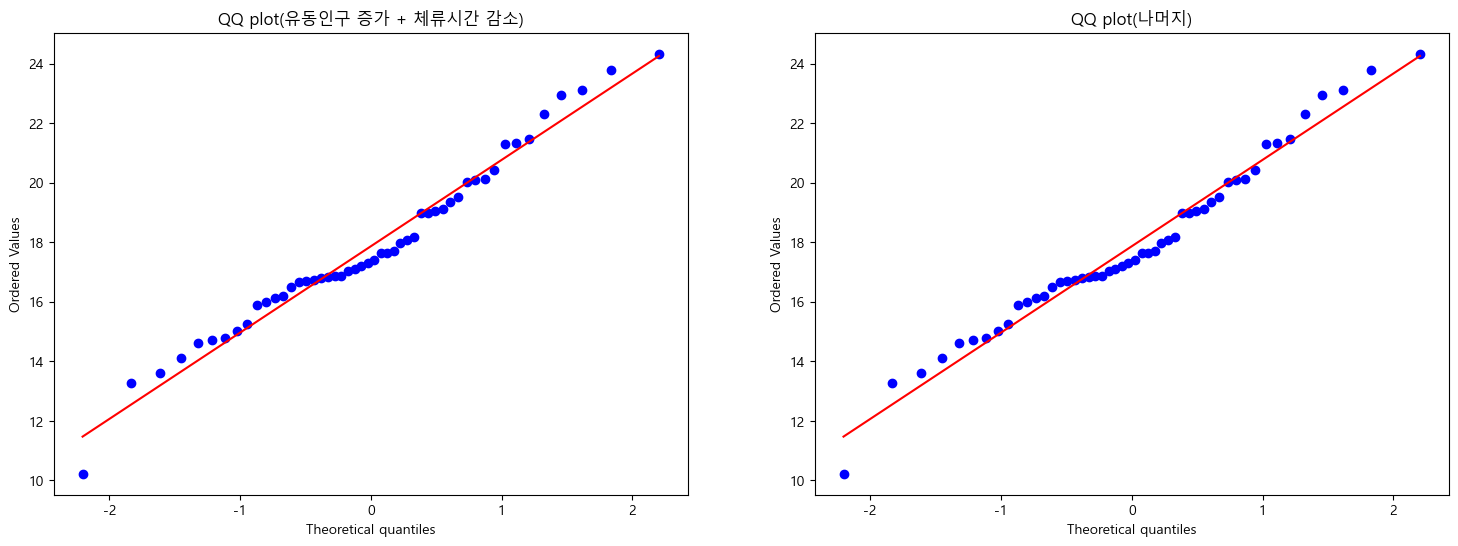

In [30]:
fig, ax = plt.subplots(1,2, figsize=(18,6))
stats.probplot(ratio_by_dong, plot=ax[0])
ax[0].set_title("QQ plot(유동인구 증가 + 체류시간 감소)")
stats.probplot(ratio_by_dong, plot=ax[1])
ax[1].set_title("QQ plot(나머지)")

plt.show()

In [ ]:
def ks_test(group):
    
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    stat, p = stats.kstest(group,'norm', args=(sample_mean, s))
    return p

ks_test(A), ks_test(B)


(np.float64(0.3778349567619197), np.float64(0.9330198866771298))

In [41]:
stat, p = stats.levene(A, B)
print(f'stat={stat:.4f}, p={p:.4f}')

stat=0.0238, p=0.8779


In [35]:
stats.ttest_ind(A, B, equal_var=True, alternative="greater")

TtestResult(statistic=np.float64(2.032579166342522), pvalue=np.float64(0.02382358744569407), df=np.float64(48.0))

In [39]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    A,
    B,
    alternative="greater"
)

print(t_stat, p_value)

print(f'유동인구 증가 + 체류시간 감소 동 수={len(A)}, 나머지 동 수={len(B)}')
print(f't_stat={t_stat:.1f}, p-value={p_value:.4f}')

2.032579166342522 0.02382358744569407
유동인구 증가 + 체류시간 감소 동 수=21, 나머지 동 수=29
t_stat=2.0, p-value=0.0238


In [34]:
# 3) Mann-Whitney U 검정 (단측: A > B)
u, p = stats.mannwhitneyu(A, B, alternative='greater')

print(f'A 동 수={len(A)}, B 동 수={len(B)}')
print(f'A 중앙값={A.median():.4f}, B 중앙값={B.median():.4f}')
print(f'U={u:.0f}, p-value={p:.4f}')

A 동 수=21, B 동 수=29
A 중앙값=17.6491, B 중앙값=16.8305
U=400, p-value=0.0309


### 유동인구 & 매출건수

In [ ]:
data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "sum", "sales_cnt": "sum"})

x = data["floating_pop"]
y = data["sales_cnt"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("sales_cnt")
plt.show()

In [ ]:
r, p_value = stats.pearsonr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

In [ ]:
r, p_value = stats.spearmanr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

### 유동인구 & 매출금액

In [ ]:
df["log_sales"] = np.log1p(df["sales_amt"])

data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "log_sales": "mean"})

x = data["floating_pop"]
y = data["log_sales"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("log(sales_amt)")
plt.show()

- 귀무가설: 유동인구와 매출금액은 상관이 없다
- 대립가설: 유동인구와 매출금액은 양의 상관이 있다.

In [ ]:
r, p_value = stats.pearsonr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

In [ ]:
r, p_value = stats.spearmanr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

유동인구와 매출금액은 강한 양의 관계

### 유동인구 & 객단가

In [ ]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]
data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "avg_ticket": "mean"})

plt.scatter(data = data, x="floating_pop", y="avg_ticket")

# x, y 값 추출
x = data["floating_pop"]
y = data["avg_ticket"]

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("avg_ticket")
plt.show()

In [ ]:
data.corr(method="pearson")

In [ ]:
data.corr(method="spearman")

In [ ]:
data.corr(method="kendall")

유동인구와 객단가는 '약한 ~ 중간 정도 상관'

- 귀무가설: 유동인구와 객단가는 상관이 없다
- 대립가설: 유동인구와 객단가는 양의 상관이 있다.

In [ ]:
r, p_value = stats.pearsonr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

In [ ]:
r, p_value = stats.spearmanr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 객단가와 객단가는 통계적으로 유의한 양의 상관관계가 있으나 상관 정도는 강하지 않다. 선형 관계가 약하고 비선형/단조 관계(값이 커질수록 같이 커지는 경향)가 보다 뚜렷하다.

In [ ]:
df.head(1)

### 상관관계
(1) 공시지가 상승률 & 개폐업률 <br>
(2) 공시지가 상승률 & 상권활력도 <br>
(3) 상권활력도 & 거래량 증감률

In [ ]:
df_land = pd.read_csv(file_path+'/법정동_분기_마스터.csv')

In [ ]:
df['prefix'] = df['adm_dong_nm'].str.replace(r'\d*동$', '', regex=True)
df_land['prefix'] = df_land['legal_dong_nm'].str.replace(r'\d*동$', '', regex=True)

In [ ]:
df_2425 = df.loc[df['year'].isin([2024, 2025])]
df_2425_land = df_land.loc[df_land['year'].isin([2024, 2025])]

In [ ]:
df_2425.head(1)

In [ ]:
df_2425_land.head(1)

In [ ]:
# 1. 전체 개폐업 점포 수
total_open_sum = df_2425['open_cnt'].sum()
total_close_sum = df_2425['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open = df_2425.groupby(['prefix', 'year'])['open_cnt'].sum().reset_index()
df_close = df_2425.groupby(['prefix', 'year'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산합니다. (동별 합계 / 전체 합계)
df_open['open_ratio'] = (df_open['open_cnt'] / total_open_sum) * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

In [ ]:
df_pct = df_open.merge(df_close, on=['prefix', 'year'], how='inner')

In [ ]:
merge_land = df_2425_land[['prefix', 'year', 'land_price_growth']].merge(
    df_pct[['prefix', 'year', 'open_ratio', 'close_ratio']], 
    on=['prefix', 'year'], 
    how='inner'
)

In [ ]:
merge_land = merge_land.drop_duplicates().reset_index(drop=True)
merge_land.head(8)

In [ ]:
# 상권 활력도
merge_land['mkt_vital'] = merge_land['open_ratio'] - merge_land['close_ratio']

In [ ]:
# 분석할 대상 리스트
targets = ["open_ratio", "close_ratio", "mkt_vital"]

for target in targets:
    x = merge_land["land_price_growth"]
    y = merge_land[target]
    
    # 1. 시각화
    plt.figure(figsize=(5, 3))
    plt.scatter(x, y, alpha=0.5, label='Data Points')
    
    # 회귀선 계산 및 그리기
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red', label=f'Regression Line')
    
    plt.xlabel("Land Price Growth (%)")
    plt.ylabel(target)
    plt.title(f"Correlation: Land Price Growth vs {target}")
    plt.legend()
    plt.show()

    # 2. 통계 검정 (Pearson & Spearman)
    pearson_r, p_p = stats.pearsonr(x, y)
    spearman_r, p_s = stats.spearmanr(x, y)
    
    print(f"--- [ Analysis for {target} ] ---")
    print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
    print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
    print("\n")

(4) 상권활력도 & 거래량 증감률

In [ ]:
# 1. 전체 개폐업 점포 수
total_open_sum = df['open_cnt'].sum()
total_close_sum = df['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open = df.groupby(['prefix', 'base_quarter'])['open_cnt'].sum().reset_index()
df_close = df.groupby(['prefix', 'base_quarter'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산합니다. (동별 합계 / 전체 합계)
df_open['open_ratio'] = (df_open['open_cnt'] / total_open_sum) * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

df_pct = df_open.merge(df_close, on=['prefix', 'base_quarter'], how='inner')

In [ ]:
df_pct['mkt_vital'] = df_pct['open_ratio'] - df_pct['close_ratio']

In [ ]:
df_land.columns

In [ ]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# 1. 동별·분기별 거래량 합계
df_land_qtr = (
    df_land.groupby(['prefix', 'base_quarter'])['transaction_cnt']
           .sum()
           .reset_index()
           .sort_values(['prefix', 'base_quarter'])
)

# 2. 전 분기 대비 거래량 증감률(%)
df_land_qtr['trans_growth'] = (
    df_land_qtr.groupby('prefix')['transaction_cnt'].pct_change() * 100
)

# 3. 상권 활력도와 병합 후 inf / NaN 제거
df_corr = (
    df_pct.merge(
        df_land_qtr[['prefix', 'base_quarter', 'trans_growth']],
        on=['prefix', 'base_quarter'], how='inner'
    )
    .replace([np.inf, -np.inf], np.nan)          # 0 → 양수일 때 생기는 inf 처리
    .dropna(subset=['mkt_vital', 'trans_growth'])
)

# (선택) 분산이 0이면 상관계수 정의 불가 → 점검
print("샘플 수:", len(df_corr))
print("mkt_vital std:", df_corr['mkt_vital'].std())
print("trans_growth std:", df_corr['trans_growth'].std())

# 4. 상관계수
pearson_r,  pearson_p  = pearsonr(df_corr['mkt_vital'],  df_corr['trans_growth'])
spearman_r, spearman_p = spearmanr(df_corr['mkt_vital'], df_corr['trans_growth'])

print(f"피어슨 상관계수 : {pearson_r:.4f} (p-value: {pearson_p:.4g})")
print(f"스피어만 상관계수: {spearman_r:.4f} (p-value: {spearman_p:.4g})")

(5) 유동인구 & 소득수준

In [ ]:
data = df[["base_quarter", "adm_dong_nm", 'floating_pop', '전입_소득수준_가중평균_분기']]


In [ ]:
x = data['floating_pop']
y = data['전입_소득수준_가중평균_분기']

# 1. 시각화
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.5, label='Data Points')

# 회귀선 계산 및 그리기
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, color='red', label=f'Regression Line')

plt.xlabel("floating_pop")
plt.ylabel("income_level")
plt.title("Correlation: floating_pop vs income_level")
plt.legend()
plt.show()

# 2. 통계 검정 (Pearson & Spearman)
pearson_r, p_p = stats.pearsonr(x, y)
spearman_r, p_s = stats.spearmanr(x, y)

print(f"--- [ Analysis for {target} ] ---")
print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
print("\n")

### 프랜차이즈 침투율 & 업종 다양성

In [ ]:
data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"franchise_ratio": "mean", "industry_diversity_H": "mean"})

x = data["franchise_ratio"]
y = data["industry_diversity_H"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("franchise_ratio")
plt.ylabel("industry_diversity_H")
plt.show()

r, p_value = stats.pearsonr(data["franchise_ratio"], data["industry_diversity_H"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(data["franchise_ratio"], data["industry_diversity_H"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

### 프랜차이즈 침투율 & 신생 점포 잔존율

In [ ]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]

data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"franchise_ratio": "mean", "survival_rate_1y": "mean"})

x = data["franchise_ratio"]
y = data["survival_rate_1y"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("franchise_ratio")
plt.ylabel("survival_rate_1y")
plt.show()

r, p_value = stats.pearsonr(data["franchise_ratio"], data["survival_rate_1y"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(data["franchise_ratio"], data["survival_rate_1y"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

### 체류시간 & 객단가

In [ ]:
# (분기, 동) 단위로 매칭
df_ticket = (df.groupby(['base_quarter', 'adm_dong_nm'], as_index=False)['avg_ticket']
               .mean())

merged = duration.merge(
    df_ticket,
    left_on=['quarter', 'adm_dong_nm'],
    right_on=['base_quarter', 'adm_dong_nm'],
    how='inner'
).dropna(subset=['duration_m', 'avg_ticket'])

x = merged["duration_m"]
y = merged["avg_ticket"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("duration_m")
plt.ylabel("avg_ticket")
plt.show()

r, p_value = stats.pearsonr(x, y)
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(x, y)
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')